# EDA with Kaggle dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


print("All imports successful!")

All imports successful!


In [5]:
#Loading and exploring dataset

df = pd.read_csv('/Users/mgmanjusha/Documents/NEU/Spring_26/FAI/Final Project/Machine-Learning-Based-Price-Fairness-Analysis-for-Laptop-E-Commerce/data/raw/laptop_cleaned2.csv')
df.head()

,Unnamed: 0,Name,Brand,Price,Rating,Processor_brand,Processor_name,Processor_variant,Processor_gen,Core_per_processor,...,Graphics_name,Graphics_brand,Graphics_GB,Graphics_integreted,Display_size_inches,Horizontal_pixel,Vertical_pixel,ppi,Touch_screen,Operating_system
0,0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,HP,50399,4.30,AMD,AMD Ryzen 5,5600H,5.0,6.0,...,AMD Radeon RX 6500M,AMD,4.0,False,15.6,1920,1080,141.21,True,Windows 11 OS
1,1,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,Lenovo,26690,4.45,AMD,AMD Ryzen 3,7320U,7.0,4.0,...,AMD Radeon Graphics,AMD,NaN,False,15.6,1920,1080,141.21,False,Windows 11 OS
2,2,HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...,HP,37012,4.65,Intel,Intel Core i3,1215U,12.0,6.0,...,Intel UHD Graphics,Intel,NaN,False,15.6,1920,1080,141.21,False,Windows 11 OS
3,3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,Samsung,69990,4.75,Intel,Intel Core i5,1240P,12.0,12.0,...,Intel Iris Xe Graphics,Intel,NaN,False,13.3,1080,1920,165.63,False,Windows 11 OS
4,4,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,Tecno,23990,4.25,Intel,Intel Core i3,1115G4,11.0,2.0,...,Intel UHD Graphics,Intel,NaN,False,15.6,1920,1080,141.21,False,Windows 11 OS


In [6]:
print("Shape: ",df.shape)

Shape:  (1020, 29)


In [7]:
print("Info: \n",df.info)

Info: 
 <bound method DataFrame.info of       Unnamed: 0                                               Name    Brand  \
0              0  HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...       HP   
1              1  Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...   Lenovo   
2              2  HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...       HP   
3              3  Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...  Samsung   
4              4  Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...    Tecno   
...          ...                                                ...      ...   
1015        1015              MSI Creator Z17 HX Studio A13V Laptop      MSI   
1016        1016  MSI Stealth 16 Mercedes AMG Motorsport A13V Ga...      MSI   
1017        1017  HP Victus 15-fb0131AX Gaming Laptop (AMD Ryzen...       HP   
1018        1018  Asus Vivobook 16 2023 M1605YA-MB521WS Laptop (...     Asus   
1019        1019  Dell Inspiron 7630 IC7630GHHRH001ORS1 2 in 1 L...     Dell   


                     count    percent
Graphics_GB            652  63.921569
Total_processor        447  43.823529
Execution_units        447  43.823529
Processor_gen          129  12.647059
Threads                 48   4.705882
Processor_variant       24   2.352941
RAM_type                22   2.156863
Core_per_processor      12   1.176471
Graphics_integreted      2   0.196078
Graphics_brand           2   0.196078
Graphics_name            2   0.196078


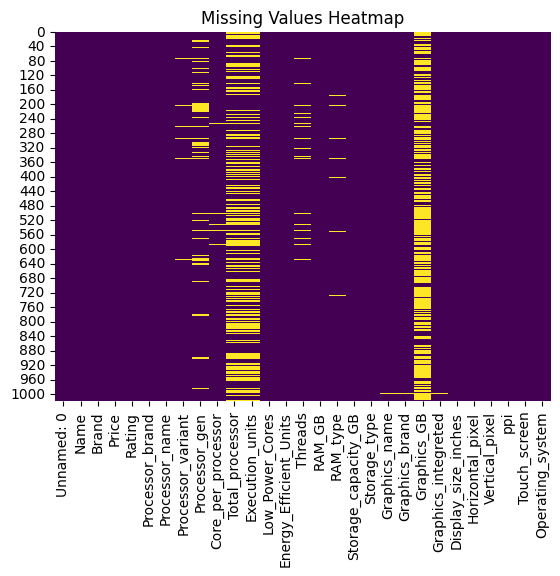

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count and percentage
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': (df.isnull().sum() / len(df) * 100)
}).sort_values('percent', ascending=False)

print(missing[missing['count'] > 0])

# Visual
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [9]:
# Step 1: Drop high-missing columns
df.drop(columns=['Graphics_GB', 'Total_processor', 'Execution_units'], inplace=True)

# Verify
print("Shape after drop:", df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after drop: (1020, 26)
Processor_variant       24
Processor_gen          129
Core_per_processor      12
Threads                 48
RAM_type                22
Graphics_name            2
Graphics_brand           2
Graphics_integreted      2
dtype: int64


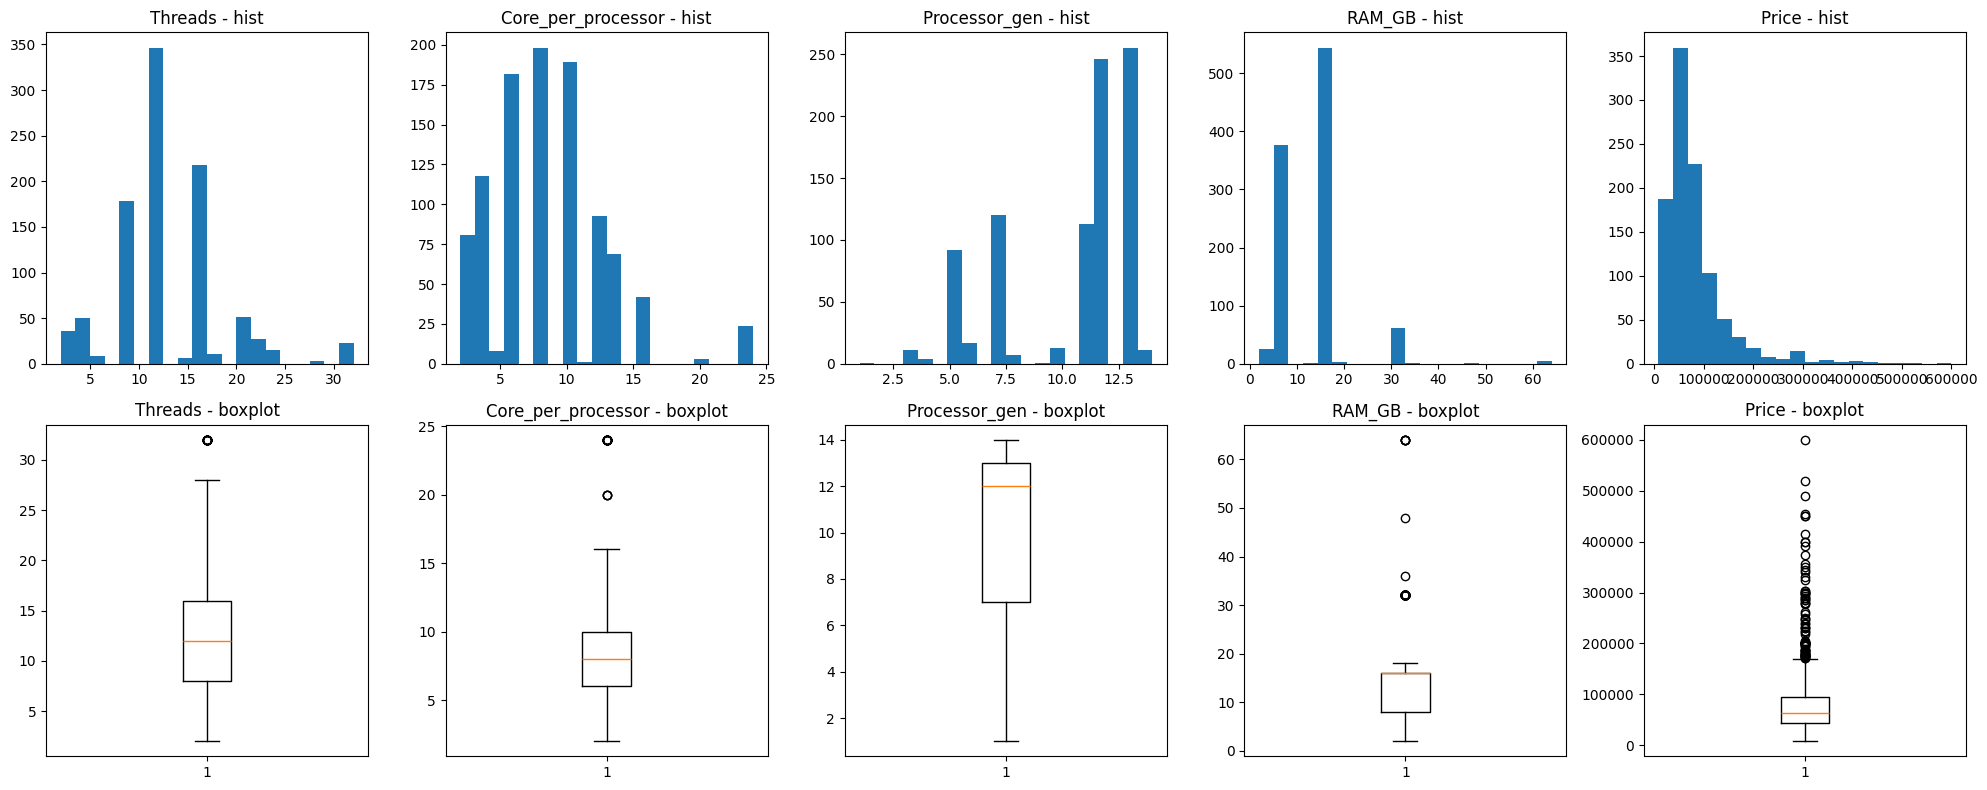

Skewness:
Threads               0.786769
Core_per_processor    1.038242
Processor_gen        -0.959187
RAM_GB                2.471612
Price                 3.023740
dtype: float64


In [10]:
#Before we impute other columns, choosing imputation technique is needed
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Threads', 'Core_per_processor', 'Processor_gen', 'RAM_GB', 'Price']

fig, axes = plt.subplots(2, len(num_cols), figsize=(20, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=20)
    axes[0, i].set_title(f'{col} - hist')
    
    # Boxplot
    axes[1, i].boxplot(df[col].dropna())
    axes[1, i].set_title(f'{col} - boxplot')

plt.tight_layout()
plt.show()

# Skewness values
print("Skewness:")
print(df[num_cols].skew())

In [11]:
# Step 2: Correct syntax
for col in ['Threads', 'Core_per_processor', 'Processor_gen']:
    df[col] = df[col].fillna(df[col].median())

# Verify
print(df[['Threads', 'Core_per_processor', 'Processor_gen']].isnull().sum())

Threads               0
Core_per_processor    0
Processor_gen         0
dtype: int64


In [12]:
# Check distribution of categorical columns with missing values
cat_cols = ['Processor_variant', 'RAM_type', 'Graphics_name', 'Graphics_brand', 'Graphics_integreted']

for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts())


Processor_variant — 125 unique values
Processor_variant
1235U        60
1215U        50
12450H       49
1335U        38
1115G4       32
             ..
processor     1
1195G7        1
10510U        1
SQ1           1
5500u         1
Name: count, Length: 125, dtype: int64

RAM_type — 12 unique values
RAM_type
DDR4       522
DDR5       188
LPDDR5     173
LPDDR4X     53
LPDDR5X     38
LPDDR4      16
DDR3         2
LPDDRX4      2
Unified      1
DDR6         1
LPDDR3       1
PDDR5X       1
Name: count, dtype: int64

Graphics_name — 136 unique values
Graphics_name
Intel Iris Xe Graphics           100
Intel UHD Graphics                84
NVIDIA GeForce RTX 3050           75
Intel Integrated Iris Xe          67
Intel Integrated UHD              62
                                ... 
Arm Mali-G72 MP3 Graphics          1
Intel Integrated ARC A530M         1
Intel Integrated ARC Graphics      1
Intel HD                           1
NVIDIA GEFORCE RTX 4050            1
Name: count, Length: 136, dt

In [13]:
# Fill with 'Unknown' where too diverse
for col in ['Processor_variant', 'Graphics_name']:
    df[col] = df[col].fillna('Unknown')

# Fill with mode where dominant value is clear
for col in ['RAM_type', 'Graphics_brand', 'Graphics_integreted']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify
print(df[['Processor_variant', 'RAM_type', 'Graphics_name', 'Graphics_brand', 'Graphics_integreted']].isnull().sum())

Processor_variant      0
RAM_type               0
Graphics_name          0
Graphics_brand         0
Graphics_integreted    0
dtype: int64


/var/folders/8j/w4cf450n1sscq6nksr6976b40000gn/T/ipykernel_12348/536994709.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [14]:
# Check no missing values remain
print("Remaining missing values:")
print(df.isnull().sum())

# Check shape
print(f"\nFinal shape: {df.shape}")

Remaining missing values:
Unnamed: 0                0
Name                      0
Brand                     0
Price                     0
Rating                    0
Processor_brand           0
Processor_name            0
Processor_variant         0
Processor_gen             0
Core_per_processor        0
Low_Power_Cores           0
Energy_Efficient_Units    0
Threads                   0
RAM_GB                    0
RAM_type                  0
Storage_capacity_GB       0
Storage_type              0
Graphics_name             0
Graphics_brand            0
Graphics_integreted       0
Display_size_inches       0
Horizontal_pixel          0
Vertical_pixel            0
ppi                       0
Touch_screen              0
Operating_system          0
dtype: int64

Final shape: (1020, 26)


In [15]:
#Checking for duplicates
print(f"Total duplicates: {df.duplicated().sum()}")

# Preview duplicate rows if any
print(df[df.duplicated(keep=False)].sort_values('Name').head(10))

Total duplicates: 0
Empty DataFrame
Columns: [Unnamed: 0, Name, Brand, Price, Rating, Processor_brand, Processor_name, Processor_variant, Processor_gen, Core_per_processor, Low_Power_Cores, Energy_Efficient_Units, Threads, RAM_GB, RAM_type, Storage_capacity_GB, Storage_type, Graphics_name, Graphics_brand, Graphics_integreted, Display_size_inches, Horizontal_pixel, Vertical_pixel, ppi, Touch_screen, Operating_system]
Index: []

[0 rows x 26 columns]


In [16]:
#Understanding the Price column
#Price is in Rupees
# Basic info about price
print("Count:", df['Price'].count())
print("Missing values:", df['Price'].isnull().sum())
print("Min price:", df['Price'].min())
print("Max price:", df['Price'].max())
print("Mean price:", df['Price'].mean())
print("Median price:", df['Price'].median())
print("Standard deviation:", df['Price'].std())

Count: 1020
Missing values: 0
Min price: 8000
Max price: 599990
Mean price: 82063.47450980393
Median price: 63689.5
Standard deviation: 66502.15060661973


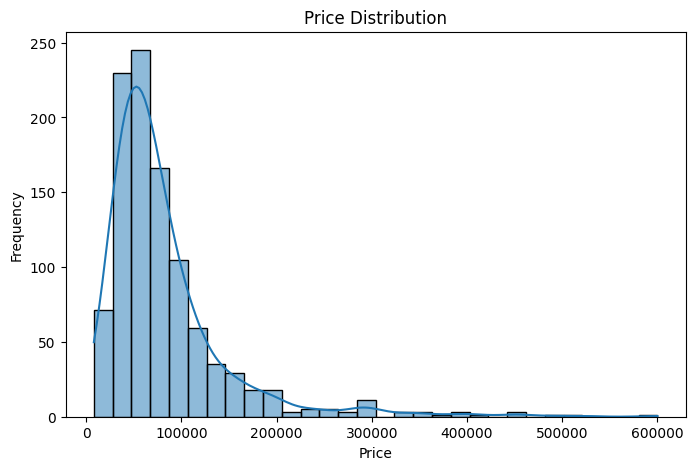

In [17]:
#Looking at the mean and median the data seemed slightly skewed
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [18]:
print("Skewness:", df['Price'].skew())

Skewness: 3.0237401709011986


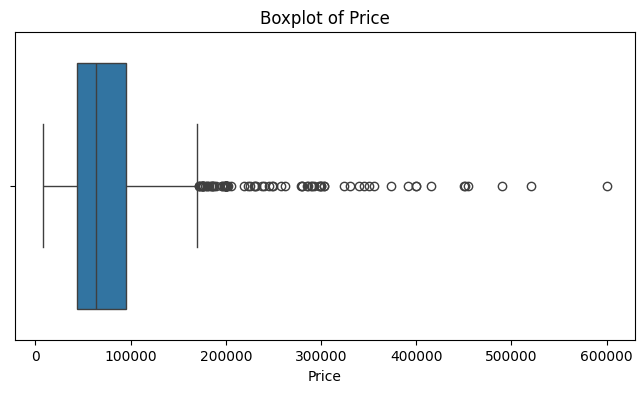

In [19]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

In [20]:
#Transforming the target variable
import numpy as np

df['Log_Price'] = np.log(df['Price'])

print("Skewness (Original):", df['Price'].skew())
print("Skewness (Log):", df['Log_Price'].skew())

Skewness (Original): 3.0237401709011986
Skewness (Log): 0.3468306356242124


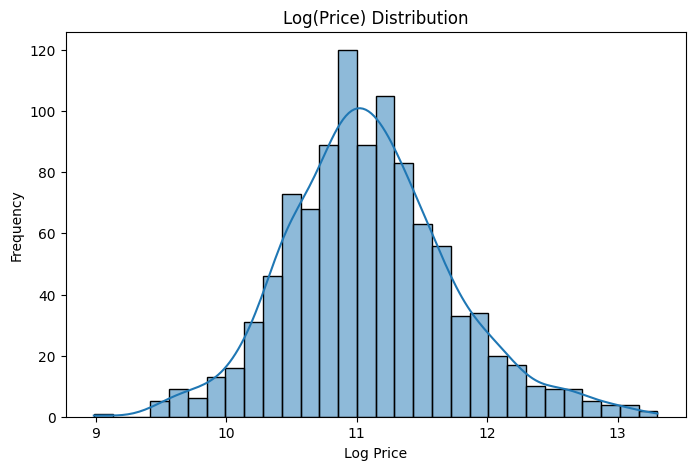

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Log_Price'], bins=30, kde=True)
plt.title("Log(Price) Distribution")
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.show()

### confirmed that the price is now normally distributed

In [22]:
# checking numerical cols
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Unnamed: 0', 'Price', 'Rating', 'Processor_gen', 'Core_per_processor',
       'Low_Power_Cores', 'Energy_Efficient_Units', 'Threads', 'RAM_GB',
       'Storage_capacity_GB', 'Display_size_inches', 'Horizontal_pixel',
       'Vertical_pixel', 'ppi', 'Log_Price'],
      dtype='object')

In [23]:
# Get all numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target and unwanted columns
remove_cols = ['Price', 'Log_Price', 'Unnamed: 0']

num_cols = [col for col in num_cols if col not in remove_cols]

num_cols

['Rating',
 'Processor_gen',
 'Core_per_processor',
 'Low_Power_Cores',
 'Energy_Efficient_Units',
 'Threads',
 'RAM_GB',
 'Storage_capacity_GB',
 'Display_size_inches',
 'Horizontal_pixel',
 'Vertical_pixel',
 'ppi']

In [24]:
df[num_cols].describe()

,Rating,Processor_gen,Core_per_processor,Low_Power_Cores,Energy_Efficient_Units,Threads,RAM_GB,Storage_capacity_GB,Display_size_inches,Horizontal_pixel,Vertical_pixel,ppi
count,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
mean,4.373676,10.646078,8.565686,0.086275,0.043137,12.779412,13.992157,627.733333,15.163775,2035.512745,1214.019608,157.178265
std,0.233295,2.819955,4.349613,0.406531,0.203266,5.544836,7.189564,316.911679,1.001537,409.209289,306.863086,33.585713
min,3.950000,1.000000,2.000000,0.000000,0.000000,2.000000,2.000000,32.000000,11.600000,1080.000000,768.000000,100.450000
25%,4.200000,10.000000,6.000000,0.000000,0.000000,8.000000,8.000000,512.000000,14.000000,1920.000000,1080.000000,141.210000
50%,4.350000,12.000000,8.000000,0.000000,0.000000,12.000000,16.000000,512.000000,15.600000,1920.000000,1080.000000,141.210000
75%,4.550000,13.000000,10.000000,0.000000,0.000000,16.000000,16.000000,512.000000,15.600000,1920.000000,1200.000000,161.730000
max,4.750000,14.000000,24.000000,2.000000,1.000000,32.000000,64.000000,4000.000000,18.000000,3840.000000,2560.000000,337.930000


# Starting feature analysis on numeric cols

## RAM GB

In [34]:
# 1. Distribution
print("Value Counts:")
print(df['RAM_GB'].value_counts().sort_index())

print(f"\nSkewness: {df['RAM_GB'].skew():.2f}")
print(df['RAM_GB'].describe())

Value Counts:
RAM_GB
2       1
4      25
8     377
12      2
16    543
18      3
32     62
36      1
48      1
64      5
Name: count, dtype: int64

Skewness: 2.47
count    1020.000000
mean       13.992157
std         7.189564
min         2.000000
25%         8.000000
50%        16.000000
75%        16.000000
max        64.000000
Name: RAM_GB, dtype: float64


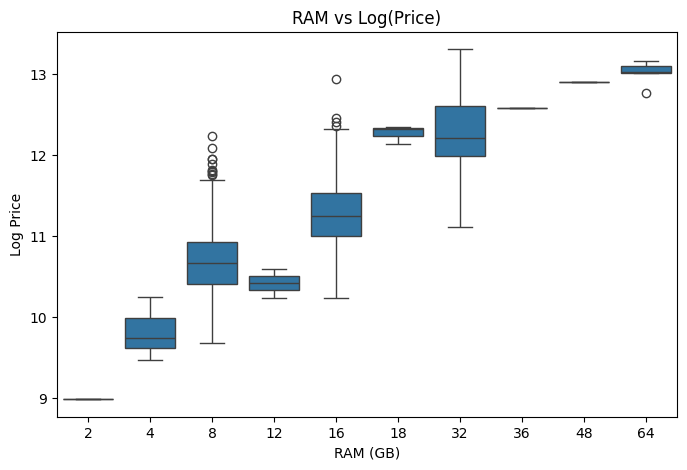

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['RAM_GB'], y=df['Log_Price'])
plt.title("RAM vs Log(Price)")
plt.xlabel("RAM (GB)")
plt.ylabel("Log Price")
plt.show()

## Observation

- Strong positive correlation between Log price and RAM GB i.e RAM GB increases with the price

Anomolies observed:

- 12GB < 8GB price, might be because omly 2 samples exist for 12 GB: not statistucally meaningful
- Some 32GB < 18GB only has 3 samples — too few to be reliable

Note for feature engineering: Binning RAM into tiers for modeling later will help. 

## Storage 

In [32]:
# 1. Distribution
print("Value Counts:")
print(df['Storage_capacity_GB'].value_counts().sort_index())

print(f"\nSkewness: {df['Storage_capacity_GB'].skew():.2f}")
print(df['Storage_capacity_GB'].describe())

Value Counts:
Storage_capacity_GB
32        1
64        9
128      19
256      46
512     702
1000    218
1256      4
1512      2
2000     18
4000      1
Name: count, dtype: int64

Skewness: 2.81
count    1020.000000
mean      627.733333
std       316.911679
min        32.000000
25%       512.000000
50%       512.000000
75%       512.000000
max      4000.000000
Name: Storage_capacity_GB, dtype: float64


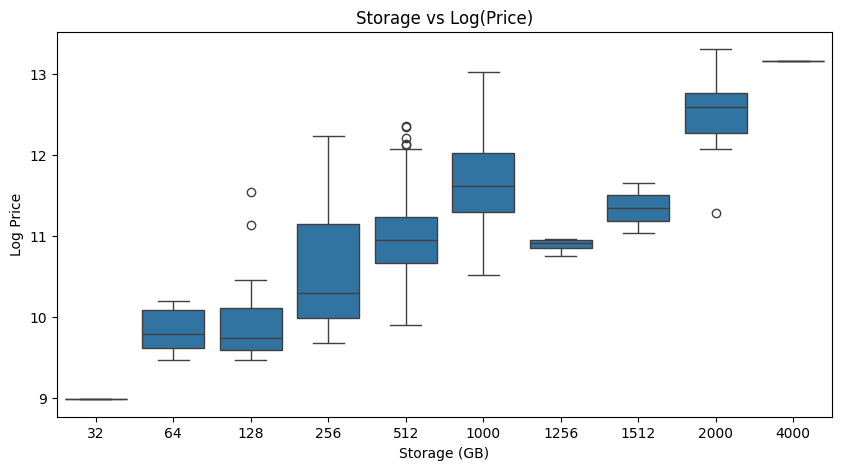

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Storage_capacity_GB'], y=df['Log_Price'])
plt.title("Storage vs Log(Price)")
plt.xlabel("Storage (GB)")
plt.ylabel("Log Price")
plt.show()

## Observation:
- Storage_capacity_GB shows a strong positive correlation with price. 

Anomolie observed:
- 1256GB and 1512GB drop below expected price trend

In [36]:
print(df[df['Storage_capacity_GB'].isin([1256, 1512])][['Name', 'Storage_capacity_GB', 'Price', 'Storage_type']])

                                                  Name  Storage_capacity_GB  \
66   MSI Thin GF63 11UC-1490IN Gaming Laptop (11th ...                 1256   
267  MSI GF63 Thin 11SC-1298IN Gaming Laptop (11th ...                 1256   
290  HP 15s-du3614TU Laptop (11th Gen Core i3/ 8GB/...                 1256   
817  MSI Thin GF63 11UCX-1492IN Gaming Laptop (11th...                 1256   
818  MSI Thin GF63 11UCX-1491IN Gaming Laptop (11th...                 1512   
936  ‎HP Zbook Power G4-A 2023 ZHAN 99 Laptop (AMD ...                 1512   

      Price     Storage_type  
66    52990  Hard Disk & SSD  
267   57990  Hard Disk & SSD  
290   46938  Hard Disk & SSD  
817   56990  Hard Disk & SSD  
818   61990  Hard Disk & SSD  
936  115558  Hard Disk & SSD  


All 6 rows have `Storage_type = "Hard Disk & SSD"`, confirming these are dual storage configurations (HDD + SSD combined), not data entry errors — 1256GB = 256GB SSD + 1TB HDD, 1512GB = 512GB SSD + 1TB HDD.

#### Note for feature engineering:
- ReMap to 1000 GB

## Processor Gen

In [39]:
# 1. Distribution
print("Value Counts:")
print(df['Processor_gen'].value_counts().sort_index())

print(f"\nSkewness: {df['Processor_gen'].skew():.2f}")
print(df['Processor_gen'].describe())

Value Counts:
Processor_gen
1.0       1
3.0      11
4.0       4
5.0      92
6.0      17
7.0     120
8.0       7
9.0       1
10.0     13
11.0    113
12.0    375
13.0    255
14.0     11
Name: count, dtype: int64

Skewness: -1.16
count    1020.000000
mean       10.646078
std         2.819955
min         1.000000
25%        10.000000
50%        12.000000
75%        13.000000
max        14.000000
Name: Processor_gen, dtype: float64


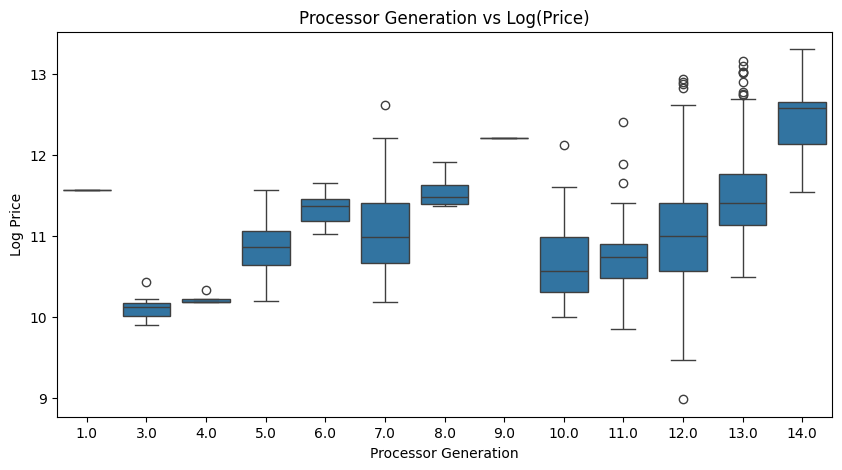

In [40]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Processor_gen'], y=df['Log_Price'])
plt.title("Processor Generation vs Log(Price)")
plt.xlabel("Processor Generation")
plt.ylabel("Log Price")
plt.show()

# Observations:

- Not a perfectly linear relationship — older gens like 7th are priced higher than 11th, likely because 7th gen laptops in this dataset are premium/workstation models
- 1st and 9th gen have only 1 sample each — unreliable, note for feature engineering
- Std is high for 12th and 13th gen — wide price range, meaning generation alone doesn't determine price

#### Note for feature engineering: 
- Processor_gen has a general but non-linear relationship with price. Gens 1 and 9 have single samples and should be flagged. Binning into Legacy (1–7), Mid (8–11), Modern (12–14) may be more effective than using raw generation numbers.

## Display Size

In [43]:
# Distribution
print("Value Counts:")
print(df['Display_size_inches'].value_counts().sort_index())

print(f"\nSkewness: {df['Display_size_inches'].skew():.2f}")
print(df['Display_size_inches'].describe())

Value Counts:
Display_size_inches
11.60     12
12.00      1
12.40      2
13.00      5
13.30     26
13.40      5
13.50      4
13.60      4
14.00    239
14.10      9
14.20      6
14.50      2
15.00      1
15.30      5
15.60    496
15.75      1
16.00    142
16.10     28
16.20      2
17.00      9
17.30     19
18.00      2
Name: count, dtype: int64

Skewness: -0.84
count    1020.000000
mean       15.163775
std         1.001537
min        11.600000
25%        14.000000
50%        15.600000
75%        15.600000
max        18.000000
Name: Display_size_inches, dtype: float64


Observations: 

- Many sizes are very close to each other: 14.0, 14.1, 14.2 - likely same physical size, just different reporting
- Same for 15.6, 15.75 and 16.0, 16.1, 16.2
- Consider binning into standard size categories in feature engineering:

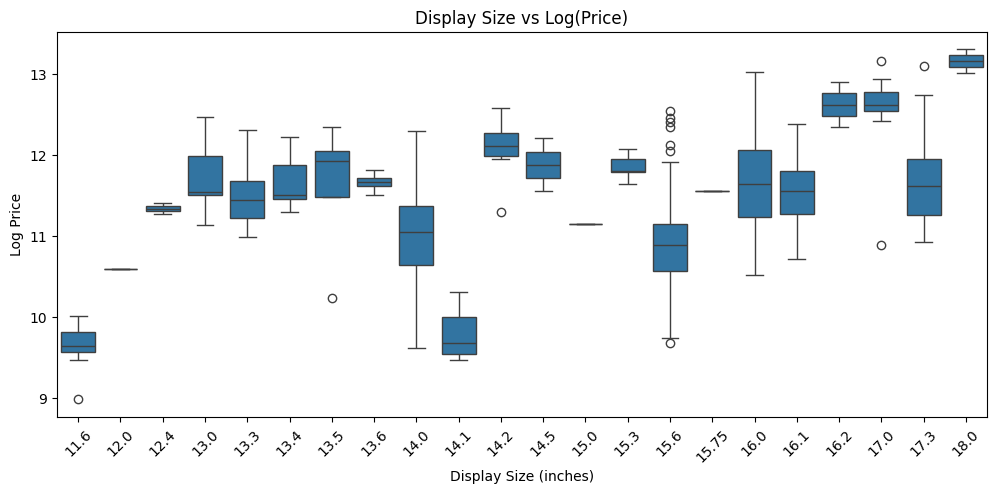

In [45]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['Display_size_inches'], y=df['Log_Price'])
plt.title("Display Size vs Log(Price)")
plt.xlabel("Display Size (inches)")
plt.ylabel("Log Price")
plt.xticks(rotation=45)
plt.show()

In [46]:
print(df.groupby('Display_size_inches')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2))

                      mean  median   std  count
Display_size_inches                            
11.60                 9.65    9.65  0.27     12
12.00                10.60   10.60   NaN      1
12.40                11.34   11.34  0.09      2
13.00                11.73   11.54  0.51      5
13.30                11.47   11.45  0.31     26
13.40                11.68   11.51  0.37      5
13.50                11.61   11.92  0.94      4
13.60                11.67   11.67  0.12      4
14.00                11.00   11.05  0.52    239
14.10                 9.82    9.68  0.33      9
14.20                12.06   12.11  0.43      6
14.50                11.88   11.88  0.46      2
15.00                11.16   11.16   NaN      1
15.30                11.85   11.80  0.17      5
15.60                10.89   10.89  0.45    496
15.75                11.56   11.56   NaN      1
16.00                11.67   11.65  0.59    142
16.10                11.53   11.56  0.42     28
16.20                12.62   12.62  0.39

# Observation:

- Not a clean linear relationship — 15.6" is cheaper than 14.0" despite being larger, likely because 15.6" is the most common budget/mid-range size
- 14.1" (9 samples, mean 9.82) is suspiciously low — could be budget ultrabooks
- Similar sizes reporting differently (14.0 vs 14.1 vs 14.2) show price variance — confirms binning is necessary

#### Note for feature analysis:
- Display size has a general but non-linear relationship with price. Sizes 14" and 15.6" dominate the dataset and represent budget-to-mid range. 
- Binning into Small/Mid/Large/XLarge categories recommended to reduce noise from near-identical size variations.

## PPI

In [48]:
# distribution
print("Value Counts:")
print(df['ppi'].value_counts().sort_index())

print(f"\nSkewness: {df['ppi'].skew():.2f}")
print(df['ppi'].describe())

Value Counts:
ppi
100.45    17
111.14     3
111.94    22
127.34    14
129.58     1
          ..
266.26     5
266.37     2
267.08     2
283.02     4
337.93     1
Name: count, Length: 62, dtype: int64

Skewness: 1.79
count    1020.000000
mean      157.178265
std        33.585713
min       100.450000
25%       141.210000
50%       141.210000
75%       161.730000
max       337.930000
Name: ppi, dtype: float64


In [49]:
print(df.groupby('ppi')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2))

         mean  median   std  count
ppi                               
100.45  10.28   10.22  0.27     17
111.14   9.64    9.68  0.08      3
111.94  10.42   10.24  0.48     22
127.34  11.45   11.40  0.36     14
129.58  10.90   10.90   NaN      1
...       ...     ...   ...    ...
266.26  11.73   11.54  0.51      5
266.37  12.70   12.70  0.11      2
267.08  11.92   11.92  0.04      2
283.02  12.71   12.71  0.17      4
337.93  12.22   12.22   NaN      1

[62 rows x 4 columns]


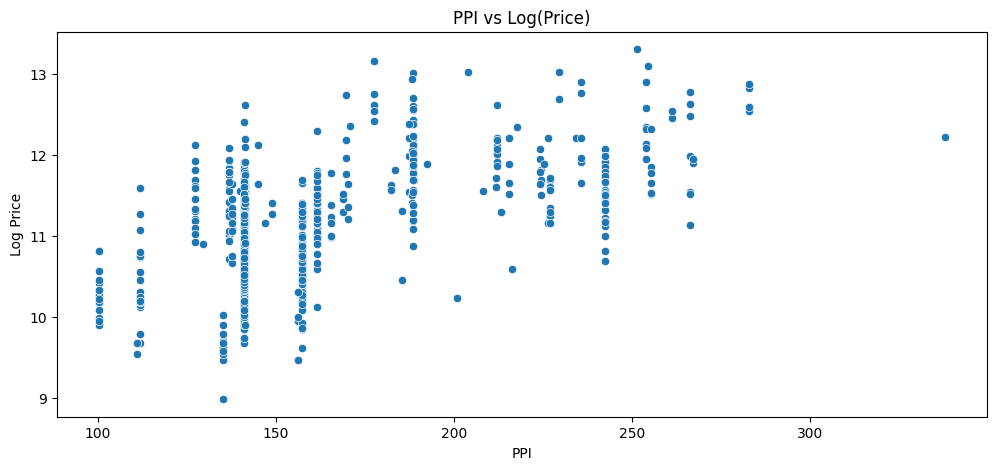

In [50]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['ppi'], y=df['Log_Price'])
plt.title("PPI vs Log(Price)")
plt.xlabel("PPI")
plt.ylabel("Log Price")
plt.show()

In [52]:
print(f"Correlation between ppi and Log_Price: {df['ppi'].corr(df['Log_Price']):.2f}")

Correlation between ppi and Log_Price: 0.58


# Observations:
- Higher ppi displays (retina, 4K) command a price premium
- Not a strong linear relationship (0.58) — ppi alone doesn't determine price, it works together with other specs

#### Note for feature engineering:
- ppi has a moderate positive correlation (0.58) with price. Since ppi is derived from resolution and screen size, Horizontal_pixel and Vertical_pixel are redundant and should be dropped during feature engineering.
- ppi has 62 unique values — we can binn into standard categories (Low, Standard, High, Very High, Ultra) during feature engineering to reduce noise and improve model performance.

# Categorical Variable analysis

## Brand

In [53]:
print("Value Counts:")
print(df['Brand'].value_counts())

print(f"\nUnique brands: {df['Brand'].nunique()}")

Value Counts:
Brand
Lenovo       217
HP           213
Asus         157
Dell         116
MSI           97
Acer          69
Samsung       32
Apple         20
Infinix       20
Chuwi          8
Zebronics      7
Microsoft      7
LG             7
Xiaomi         6
Gigabyte       6
Honor          6
Avita          6
Ultimus        5
Wings          3
Fujitsu        3
Primebook      3
Huawei         2
AXL            2
Jio            1
Ninkear        1
ASUS           1
Walker         1
iBall          1
Tecno          1
Razer          1
Colorful       1
Name: count, dtype: int64

Unique brands: 31


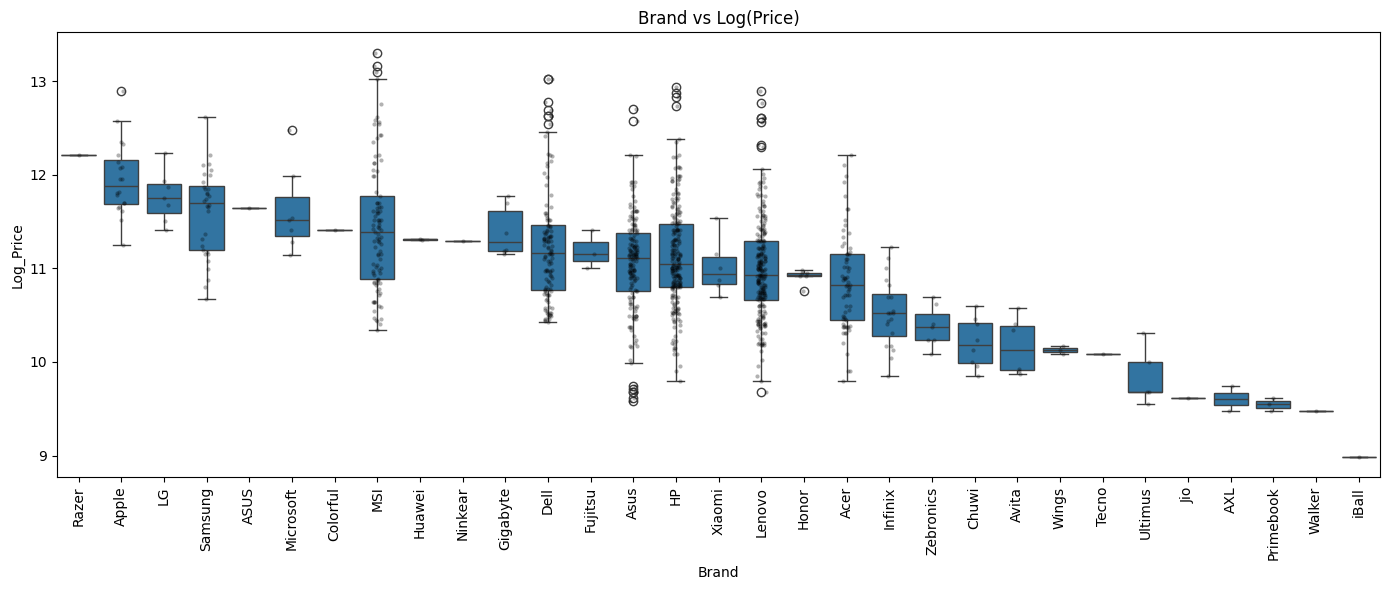

In [58]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='Brand', y='Log_Price', data=df, order=df.groupby('Brand')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Brand', y='Log_Price', data=df, order=df.groupby('Brand')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.xticks(rotation=90)
plt.title("Brand vs Log(Price)")
plt.tight_layout()
plt.show()

## Observations:
- Clear brand-based price segmentation 
- Apple, LG, Microsoft command significant premium
- Lenovo and HP are mid-range despite being most common in dataset
- Single sample brands are unreliable for modeling
- ASUS and Asus are the same brand — data quality issue, needs fixing
- Single entry brands (Jio, Ninkear, Walker, iBall, Razer, Colorful) — very few samples, unreliable


#### Note for Feature Engineering:

- Consider creating brand tier feature: Premium / Mid-High / Mid / Budget
- Standardize all brand names to title case using df['Brand'] = df['Brand'].str.strip().str.title() to fix inconsistencies like ASUS vs Asus.
- Group rare brands with very few samples (Jio, Ninkear, Walker, iBall, Razer, Colorful, etc.) into an Other category to reduce noise in modeling.



## Processor Brand

In [59]:
print("Value Counts:")
print(df['Processor_brand'].value_counts())

print(f"\nUnique processor brands: {df['Processor_brand'].nunique()}")

Value Counts:
Processor_brand
Intel        742
AMD          250
Apple         18
MediaTek       7
Qualcomm       1
Microsoft      1
HiSilicon      1
Name: count, dtype: int64

Unique processor brands: 7


                  mean  median   std  count
Processor_brand                            
Qualcomm         12.00   12.00   NaN      1
Apple            11.95   11.88  0.40     18
HiSilicon        11.31   11.31   NaN      1
Intel            11.14   11.11  0.65    742
Microsoft        11.14   11.14   NaN      1
AMD              10.96   10.93  0.47    250
MediaTek          9.70    9.62  0.24      7


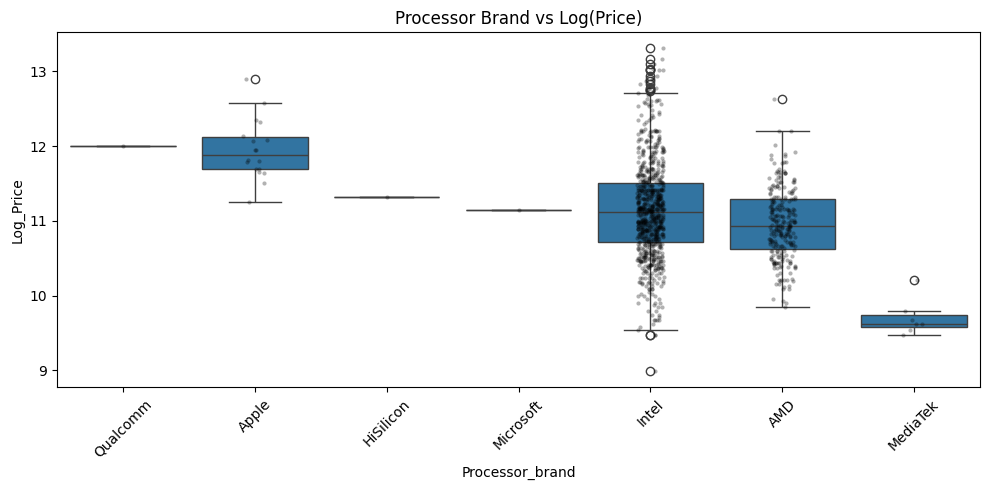

In [60]:
print(df.groupby('Processor_brand')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False))

plt.figure(figsize=(10, 5))
sns.boxplot(x='Processor_brand', y='Log_Price', data=df, order=df.groupby('Processor_brand')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Processor_brand', y='Log_Price', data=df, order=df.groupby('Processor_brand')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.title("Processor Brand vs Log(Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation:
- Clear processor brand price segmentation 
- Apple chips significantly more expensive than Intel/AMD
- Intel vs AMD difference is small (0.18) — not a strong differentiator
- MediaTek clearly budget segment

#### Note for feature engineering:
- Group Qualcomm, Microsoft, HiSilicon (1 sample each) into Other category. 
- Create processor tier feature: Premium(Apple) / Standard(Intel, AMD) / Budget(MediaTek, Other)

## Storage type

In [61]:
print("Value Counts:")
print(df['Storage_type'].value_counts())

print(f"\nUnique storage types: {df['Storage_type'].nunique()}")

Value Counts:
Storage_type
 SSD               999
 Hard Disk          14
Hard Disk & SSD      6
 NVMe SSD            1
Name: count, dtype: int64

Unique storage types: 4


In [62]:
print(df['Storage_type'].unique())

[' SSD' 'Hard Disk & SSD' ' NVMe SSD' ' Hard Disk']
